In [10]:
import numpy as np
def softmax(x):
    return np.exp(x)/np.sum(np.exp(x))

x = np.array([10,2,1000,1000])
print(softmax(x))
print(x-x.max())
print(softmax(x-x.max()))

[ 0.  0. nan nan]
[-990 -998    0    0]
[0.  0.  0.5 0.5]


/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_9683/2803684558.py:3: RuntimeWarning: overflow encountered in exp
  return np.exp(x)/np.sum(np.exp(x))
/var/folders/w5/dbynx6_n5dx4dmbs318q61s00000gn/T/ipykernel_9683/2803684558.py:3: RuntimeWarning: invalid value encountered in divide
  return np.exp(x)/np.sum(np.exp(x))


Iteration 50/10000, Loss: 6.8628
Iteration 100/10000, Loss: 5.7958
Iteration 150/10000, Loss: 5.1263
Iteration 200/10000, Loss: 4.6920
Iteration 250/10000, Loss: 4.3655
Iteration 300/10000, Loss: 4.0973
Iteration 350/10000, Loss: 3.8674
Iteration 400/10000, Loss: 3.6653
Iteration 450/10000, Loss: 3.4849
Iteration 500/10000, Loss: 3.3219
Iteration 550/10000, Loss: 3.1736
Iteration 600/10000, Loss: 3.0377
Iteration 650/10000, Loss: 2.9128
Iteration 700/10000, Loss: 2.7974
Iteration 750/10000, Loss: 2.6905
Iteration 800/10000, Loss: 2.5912
Iteration 850/10000, Loss: 2.4987
Iteration 900/10000, Loss: 2.4123
Iteration 950/10000, Loss: 2.3315
Iteration 1000/10000, Loss: 2.2558
Iteration 1050/10000, Loss: 2.1848
Iteration 1100/10000, Loss: 2.1181
Iteration 1150/10000, Loss: 2.0553
Iteration 1200/10000, Loss: 1.9962
Iteration 1250/10000, Loss: 1.9405
Iteration 1300/10000, Loss: 1.8879
Iteration 1350/10000, Loss: 1.8382
Iteration 1400/10000, Loss: 1.7912
Iteration 1450/10000, Loss: 1.7468
Itera

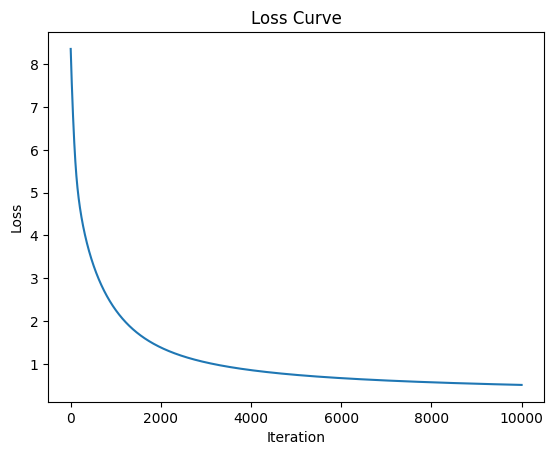

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载数据
d = np.load('usps.npz')
X_tr, y_tr, X_te, y_te = d['X_tr'], d['y_tr'], d['X_te'], d['y_te']

# 2. 参数设置
num_classes = 10          # 分类类别数（数字 0-9）
num_features = X_tr.shape[1]  # 特征数（256）
learning_rate = 0.01       # 学习率
max_iter = 10000             # 最大迭代次数

# 3. Softmax 函数实现
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)  # 防止溢出
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 4. One-hot 编码
def one_hot_encoding(y, num_classes):
    return np.eye(num_classes)[y]

# 5. 计算负对数似然损失和梯度
def compute_loss_and_gradient(X, y, W):
    # 样本数量
    num_samples = X.shape[0]
    # 计算得分
    scores = X @ W
    # 计算 softmax 概率
    probs = softmax(scores)
    # 计算负对数似然损失
    y_one_hot = one_hot_encoding(y, num_classes)
    loss = -np.sum(y_one_hot * np.log(probs + 1e-8)) / num_samples

    # 计算梯度
    gradient = X.T @ (probs - y_one_hot) / num_samples
    return loss, gradient

# 6. 模型训练
def train(X, y, num_classes, learning_rate, max_iter):
    # 从高斯分布中随机初始化权重矩阵 W
    W = np.random.randn(X.shape[1], num_classes)

    # 存储损失值
    losses = []

    # 梯度下降优化
    for t in range(max_iter):
        loss, gradient = compute_loss_and_gradient(X, y, W)
        W -= learning_rate * gradient  # 参数更新
        losses.append(loss)

        # 每 50 次迭代打印一次损失
        if (t + 1) % 50 == 0:
            print(f'Iteration {t + 1}/{max_iter}, Loss: {loss:.4f}')

    return W, losses

# 7. 模型预测
def predict(X, W):
    scores = X @ W
    return np.argmax(scores, axis=1)

# 8. 计算准确率
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# 9. 训练模型
W, losses = train(X_tr, y_tr, num_classes, learning_rate, max_iter)

# 10. 在训练集和测试集上进行预测
train_pred = predict(X_tr, W)
test_pred = predict(X_te, W)

# 11. 计算准确率
train_acc = accuracy(y_tr, train_pred)
test_acc = accuracy(y_te, test_pred)

print(f'Training Accuracy: {train_acc * 100:.2f}%')
print(f'Test Accuracy: {test_acc * 100:.2f}%')

# 12. 绘制损失曲线
plt.plot(range(max_iter), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()


In [14]:
train_num = X_tr.shape[0]
test_num = X_te.shape[0]
for i in range(10):
    print(f'Train Class {i} num: {(y_tr==i).sum()}, ratio: {((y_tr==i).sum())/train_num*100:.2f}%')
    print(f'Test Class {i} num: {(y_te==i).sum()}, ratio: {((y_te==i).sum())/test_num*100:.2f}%')


Train Class 0 num: 1194, ratio: 16.38%
Test Class 0 num: 359, ratio: 17.89%
Train Class 1 num: 1005, ratio: 13.78%
Test Class 1 num: 264, ratio: 13.15%
Train Class 2 num: 731, ratio: 10.03%
Test Class 2 num: 198, ratio: 9.87%
Train Class 3 num: 658, ratio: 9.02%
Test Class 3 num: 166, ratio: 8.27%
Train Class 4 num: 652, ratio: 8.94%
Test Class 4 num: 200, ratio: 9.97%
Train Class 5 num: 556, ratio: 7.63%
Test Class 5 num: 160, ratio: 7.97%
Train Class 6 num: 664, ratio: 9.11%
Test Class 6 num: 170, ratio: 8.47%
Train Class 7 num: 645, ratio: 8.85%
Test Class 7 num: 147, ratio: 7.32%
Train Class 8 num: 542, ratio: 7.43%
Test Class 8 num: 166, ratio: 8.27%
Train Class 9 num: 644, ratio: 8.83%
Test Class 9 num: 177, ratio: 8.82%


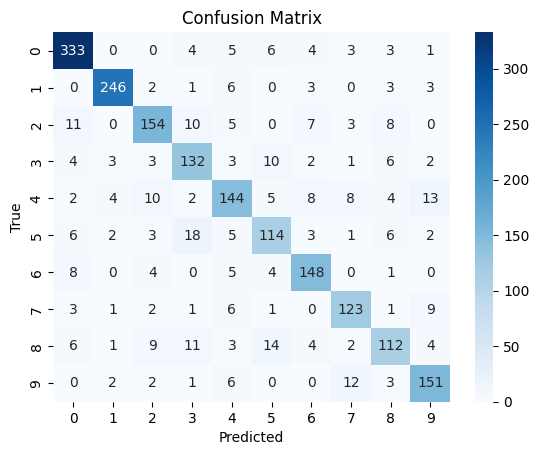

In [16]:
# 绘制混淆矩阵
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
